In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/kecelakaan-with-location-geoencoded.csv')

In [ ]:
df.head()

,created_at,text,location,coordinates
0,2025-07-10T13:25:43.307626Z,[Breaking News] 01:32 wib info awal terjadi ke...,"[""Denggung Sleman Yogyakarta""]",NaN
1,2025-07-10T13:25:51.326578Z,"Ijin share min, hampir saja dapat musibah gara...","[""Utara TB Vijaya, Ringroad manding, Bantul""]","(-7.7581639, 110.3862923)"
2,2025-07-10T13:26:11.269208Z,Min izin menginfokan ada mobil masuk selokan m...,"[""RS.Hermina"", ""selokan mataram deket""]","(-7.7619263, 110.28743424999999)"
3,2025-07-10T13:26:50.365213Z,"Min area hos Cokroaminoto ada pipa PDAM bocor,...","[""hos Cokroaminoto""]","(-7.8012646, 110.3646857)"
4,2025-07-10T13:27:04.923249Z,min leher saya kena senar layang layang di Fly...,"["" Lempuyangan"", ""di FlyOver L""]","(-7.8012646, 110.3646857)"


In [ ]:
df.isna().sum()

,0
created_at,0
text,0
location,10
coordinates,47


In [ ]:
df.dropna(subset=["location"], inplace=True)

In [ ]:
df.isna().sum()

,0
created_at,0
text,0
location,0
coordinates,37


In [ ]:
df[df['coordinates'].isna()]

,created_at,text,location,coordinates
0,2025-07-10T13:25:43.307626Z,[Breaking News] 01:32 wib info awal terjadi ke...,"[""Denggung Sleman Yogyakarta""]",NaN
5,2025-07-10T13:27:31.911181Z,"Min, selamat pagi. \nMaaf izin melaporkan, kes...","[""pasar Giwangan""]",NaN
8,2025-07-10T13:28:01.589392Z,Senar layangan nyilakani tenan min. Korbannya ...,"[""Gambiran Yogyakarta""]",NaN
13,2025-07-10T13:29:38.044784Z,"Min, barusan di jl. Solo ada 3 motor jatuh kar...","[""jl. Solo""]",NaN
15,2025-07-10T13:30:00.428029Z,"menginformasikan min, terjadi kebarakan mobil ...","[""di Jalan Kaliurang km 20""]",NaN
16,2025-07-10T13:30:13.465347Z,"[Breaking News] ada truk njeglong,\nbarusan.,,...","[""maguwo RT 16 banguntapan bantul"", ""SMA 1 Ban...",NaN
19,2025-07-10T13:31:03.425250Z,[Breaking News] terjadi kecelakaan andong ket...,"[""rskia bunda""]",NaN
22,2025-07-10T13:31:50.798530Z,[Breaking News] 16:45 terjadi laka antara mobi...,"[""jalan Parangtritis Yogyakarta"", ""ISI ""]",NaN
23,2025-07-10T13:32:00.086154Z,"Jembatan janti arah blok o macet, ada laka tru...","[""Jembatan janti ""]",NaN
25,2025-07-10T13:32:17.535532Z,[Breaking News] lagi wae truck terguling ngang...,"[""Qhomemart""]",NaN


In [ ]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd
import json

geolocator = Nominatim(user_agent="kecelakaan-ner-mapper")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

results = []

known_locations = {
    "jalan kaliurang": "jalan kaliurang",
    "jakal": "jalan kaliurang",
    "sedayu": "sedayu",
    "Jl kabupaten": "Jl kabupaten",
    "jalan kabupaten": "Jl kabupaten",
    "wates": "Jl wates",
    "selokan mataram": "selokan mataram",
    "ringroad": "ringroad",
    "Bantul": "Bantul",
    "Sleman": "Sleman",
    "Yogyakarta": "Yogyakarta",
    "Kulon Progo": "Kulon Progo",
    "Gunung Kidul": "Gunung Kidul",
    "Kota Yogyakarta": "Kota Yogyakarta",
    "sagan": "sagan",
    "prambanan": "prambanan",
    "pakualaman": "pakualaman",
    "semanu": "jl semanu",
    "UPN": "UPN",
    "UII": "UII",
    "selomartani": "selomartani",
    "Turi": "Turi",
    "sungai gajah": "gajah wong",
    "siyono": "siyono",
    "kentungan": "kentungan",
    "tugu": "malioboro",
    "giwangan": "giwangan"
}

In [ ]:
for row in df[df['coordinates'].isna()]["location"]:
  locations = json.loads(row)
  location_result = []
  for loc in locations:
    loc = loc.strip()
    temp_result = []
    for know_loc in known_locations.keys():
      if know_loc in loc:
        loc = known_locations[know_loc]
        break
    location = geocode(loc + ",Yogyakarta, Indonesia")
    if location is None:
      print(loc, "not found")
      continue
    temp_result.append((location.latitude, location.longitude))
    location_avg = np.mean(temp_result, axis=0)
    print(location_avg)
  location_result.append(tuple(location_avg))


  # print(row)

[ -7.6894175 110.3812904]
[ -7.8317337 110.3890706]
[ -7.8012646 110.3646857]
[ -7.7833681 110.4193372]
[ -7.7501062 110.3860446]
[ -7.7985605 110.410027 ]


[ -7.8091445 110.4165692]
[ -7.8206723 110.3997245]
[ -7.8012646 110.3646857]
[ -7.8529764 110.3567229]
[ -7.7857615 110.410436 ]
[ -7.7956849 110.4096338]
[ -7.6894175 110.3812904]
[ -7.6829592 110.4215262]
[ -7.6982132 110.4448801]
[ -7.6982132 110.4448801]
[ -7.7847888 110.4961947]
[ -7.7808728 110.3487419]
[ -7.7757693 110.361154 ]


[ -7.6349649 110.4253783]


[ -7.7581639 110.3862923]


[ -7.8084033 110.3894368]
[ -7.7520157 110.4914556]


...

[ -7.7491925 110.3720721]
[ -7.8982544 110.3855534]


[ -7.8338191 110.2188429]


[ -7.8330221 110.3902376]


[ -7.7697036 110.3686205]
[ -7.7761953 110.3762098]


[ -7.7834366 110.4435054]
[ -7.7471001 110.4675544]
[ -7.8012646 110.3646857]
[ -7.8116686 110.4088085]
[ -7.8116686 110.4088085]
[ -7.8561563 110.352463 ]
[ -7.8529764 110.3567229]
[ -7.7810248 110.4320498]


In [ ]:
location_result

[(np.float64(-7.7810248), np.float64(110.4320498))]

In [ ]:
# fill the missing value with location_result
df.loc[df['coordinates'].isna(), 'coordinates'] = location_result

In [ ]:
df.isna().sum()

,0
created_at,0
text,0
location,0
coordinates,0


In [ ]:
df.to_csv('kecelakaan-with-location-geocoded-no-missing.csv')

In [ ]:
df['coordinates']

,coordinates
0,"(-7.7810248, 110.4320498)"
1,"(-7.7581639, 110.3862923)"
2,"(-7.7619263, 110.28743424999999)"
3,"(-7.8012646, 110.3646857)"
4,"(-7.8012646, 110.3646857)"
...,...
96,"(-7.7810248, 110.4320498)"
98,"(-7.7810248, 110.4320498)"
99,"(-7.7810248, 110.4320498)"
100,"(-7.8004337, 110.3762266)"


In [ ]:
import pandas as pd
import ast
import numpy as np

def extract_lat_lon(coord):
    if isinstance(coord, (list, tuple, np.ndarray)):
        if len(coord) == 2:
            return pd.Series([float(coord[0]), float(coord[1])])
    else:
        try:
            parsed = ast.literal_eval(str(coord))
            if isinstance(parsed, (list, tuple)) and len(parsed) == 2:
                return pd.Series([float(parsed[0]), float(parsed[1])])
        except Exception:
            print(f"Error parsing {coord}")
            pass
    return pd.Series([None, None])
df[['latitude', 'longitude']] = df['coordinates'].apply(extract_lat_lon)


In [ ]:
df.head()

,created_at,text,location,coordinates,latitude,longitude
0,2025-07-10T13:25:43.307626Z,[Breaking News] 01:32 wib info awal terjadi ke...,"[""Denggung Sleman Yogyakarta""]","(-7.7810248, 110.4320498)",-7.781025,110.432050
1,2025-07-10T13:25:51.326578Z,"Ijin share min, hampir saja dapat musibah gara...","[""Utara TB Vijaya, Ringroad manding, Bantul""]","(-7.7581639, 110.3862923)",-7.758164,110.386292
2,2025-07-10T13:26:11.269208Z,Min izin menginfokan ada mobil masuk selokan m...,"[""RS.Hermina"", ""selokan mataram deket""]","(-7.7619263, 110.28743424999999)",-7.761926,110.287434
3,2025-07-10T13:26:50.365213Z,"Min area hos Cokroaminoto ada pipa PDAM bocor,...","[""hos Cokroaminoto""]","(-7.8012646, 110.3646857)",-7.801265,110.364686
4,2025-07-10T13:27:04.923249Z,min leher saya kena senar layang layang di Fly...,"["" Lempuyangan"", ""di FlyOver L""]","(-7.8012646, 110.3646857)",-7.801265,110.364686


In [ ]:
df.to_csv("kecelakaan-with-location-lat-long.csv")

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

# Convert lat/lon to radians for haversine distance
coords = np.radians(df[['latitude', 'longitude']])

# Run DBSCAN with haversine distance (Earth distance)
kms_per_radian = 6371.0088
epsilon = 1.5 / kms_per_radian  # 1.5 km radius

db = DBSCAN(eps=epsilon, min_samples=5, algorithm='ball_tree', metric='haversine')
cluster_labels = db.fit_predict(coords)
df['cluster'] = cluster_labels


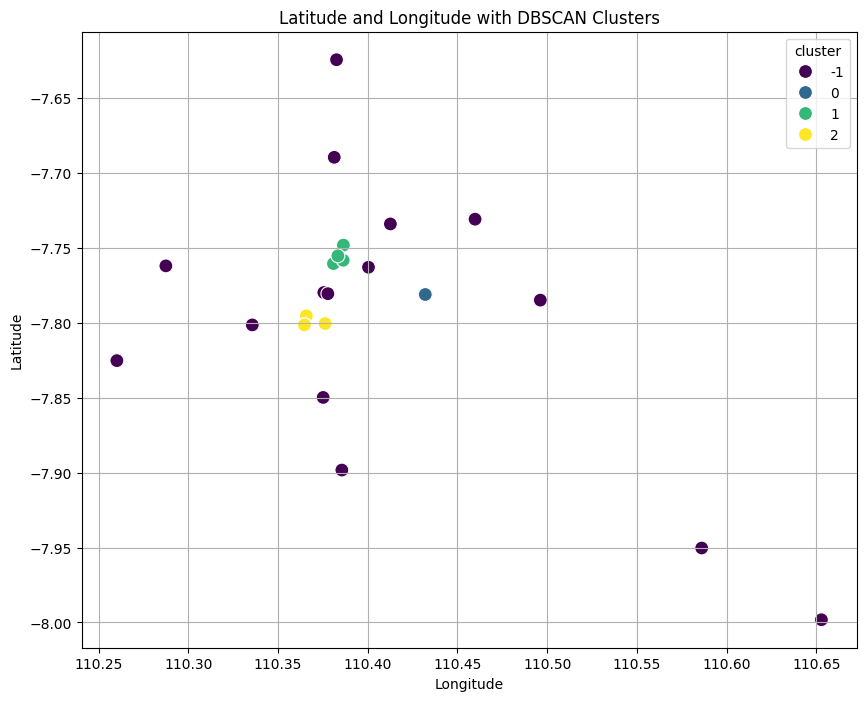

In [ ]:
# prompt: plot latitude and longitude with colored cluster

import matplotlib.pyplot as plt
import seaborn as sns

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='cluster', palette='viridis', s=100, legend='full')
plt.title('Latitude and Longitude with DBSCAN Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

In [ ]:
!pip install scikit-learn-extra

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

# Assume your DataFrame has 'latitude' and 'longitude' columns
X = df[['latitude', 'longitude']].to_numpy()

# Set number of clusters (e.g., 5 hotspots)
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

# Assign cluster to each point
df['cluster'] = kmeans.labels_

# Get cluster centers
cluster_centers = kmeans.cluster_centers_

# Show them
for i, (lat, lon) in enumerate(cluster_centers):
    print(f"Cluster {i}: Lat = {lat}, Lon = {lon}")


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7c7fae4d6700>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


Cluster 0: Lat = -7.7784524119047616, Lon = 110.43454869642858
Cluster 1: Lat = -7.799327201190476, Lon = 110.36822972142856
Cluster 2: Lat = -7.65683995, Lon = 110.381933
Cluster 3: Lat = -7.97426005, Lon = 110.61954449999999
Cluster 4: Lat = -7.8041035, Lon = 110.26922148333333


In [ ]:
# export cluster_center to csv
cluster_centers = pd.DataFrame(cluster_centers, columns=['latitude', 'longitude'])
cluster_centers.to_csv('cluster_centers.csv')

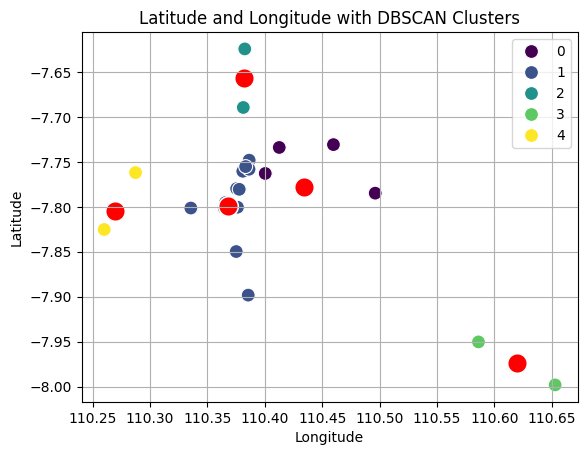

In [ ]:
# plot cluser along with dbscan
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting
sns.scatterplot(data=df, x='longitude', y='latitude', hue='cluster', palette='viridis', s=100, legend='full')
sns.scatterplot(data=cluster_centers, x='longitude', y='latitude', color='red', s=200)
plt.title('Latitude and Longitude with DBSCAN Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)